# =============================================================================
# PHASE 1: BUSINESS UNDERSTANDING
# =============================================================================

## Business Problem

An e-commerce company has introduced a new landing page and wants to evaluate
whether it performs better than the existing landing page.

The company wants to determine whether the new landing page increases user
conversion rates enough to replace the old landing page.

---

## Business Objective

The objective of this A/B test is to compare the performance of:

- Control Group - Users exposed to the old landing page
- Treatment Group - Users exposed to the new landing page

The analysis will determine whether the new landing page creates a statistically
significant improvement in conversion rate.

---

## Experiment Design

### Experiment Type

A/B Testing (Randomized Controlled Experiment)

### Groups

| Group | Description |
|-------|-------------|
| Control | Users who viewed the old landing page |
| Treatment | Users who viewed the new landing page |

### Experiment Unit

Individual website visitors.

---

## Key Performance Indicator (KPI)

### Primary KPI

Conversion Rate

Conversion Rate = Converted Users / Total Users


### Secondary KPIs

- Conversion Rate Difference
- Absolute Lift
- Relative Lift
- Statistical Significance
- Business Impact

---

## Hypothesis Definition

### Null Hypothesis (H0)

There is no significant difference between the conversion rates
of the old and new landing pages.

H0:
Conversion Rate(New Page) = Conversion Rate(Old Page)


### Alternative Hypothesis (H1)

The new landing page has a different conversion rate compared
to the old landing page.

H1:
Conversion Rate(New Page) != Conversion Rate(Old Page)

---

## Success Criteria

The new landing page will be considered successful if:

1. Conversion rate is higher than the old page.
2. The difference is statistically significant.
3. P-value is less than 0.05.
4. Improvement creates meaningful business value.

---

## Expected Outcome

The analysis will help stakeholders decide whether to:

✅ Launch the new landing page

OR

❌ Continue using the existing landing page.

In [6]:
# =============================================================================
# PHASE 2: DATA UNDERSTANDING
# Load the dataset, inspect its structure, understand each feature,
# review data types, and perform an initial quality assessment.
# =============================================================================

import pandas as pd
from scipy.stats import chisquare
# -----------------------------
# 1. Load Dataset
# -----------------------------
df = pd.read_csv("ab_data.csv")

# Convert timestamp to datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# -----------------------------
# 2. Dataset Overview
# -----------------------------
print("=" * 60)
print("DATA UNDERSTANDING")
print("=" * 60)

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print()

# -----------------------------
# 3. First Five Records
# -----------------------------
print("=" * 60)
print("FIRST FIVE ROWS")
print("=" * 60)

print(df.head())
print()

# -----------------------------
# 4. Dataset Information
# -----------------------------
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

df.info()

print()

# -----------------------------
# 5. Statistical Summary
# -----------------------------
print("=" * 60)
print("NUMERICAL SUMMARY")
print("=" * 60)

print(df.describe())

print()

print("=" * 60)
print("CATEGORICAL SUMMARY")
print("=" * 60)

print(df.describe(include=["object", "string"]))

print()

# -----------------------------
# 6. Missing Values
# -----------------------------
print("=" * 60)
print("MISSING VALUES")
print("=" * 60)

print(df.isnull().sum())

print()

# -----------------------------
# 7. Duplicate Records
# -----------------------------
print("=" * 60)
print("DUPLICATE RECORDS")
print("=" * 60)

print(df.duplicated().sum())

print()

# -----------------------------
# 8. Column Names
# -----------------------------
print("=" * 60)
print("COLUMN NAMES")
print("=" * 60)

print(df.columns.tolist())

print()

# -----------------------------
# 9. Data Types
# -----------------------------
print("=" * 60)
print("DATA TYPES")
print("=" * 60)

print(df.dtypes)

print()

# -----------------------------
# 10. Unique Values
# -----------------------------
print("=" * 60)
print("UNIQUE VALUES")
print("=" * 60)

for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

print()

# -----------------------------
# 11. Group Distribution
# -----------------------------
print("=" * 60)
print("GROUP DISTRIBUTION")
print("=" * 60)

print(df["group"].value_counts())

print()

# -----------------------------
# 12. Landing Page Distribution
# -----------------------------
print("=" * 60)
print("LANDING PAGE DISTRIBUTION")
print("=" * 60)

print(df["landing_page"].value_counts())

print()

# -----------------------------
# 13. Conversion Distribution
# -----------------------------
print("=" * 60)
print("CONVERSION DISTRIBUTION")
print("=" * 60)

print(df["converted"].value_counts())

print()

# -----------------------------
# 14. Date Range
# -----------------------------
print("=" * 60)
print("EXPERIMENT DURATION")
print("=" * 60)

print("Start :", df["timestamp"].min())
print("End   :", df["timestamp"].max())
print("Days  :", (df["timestamp"].max() - df["timestamp"].min()).days)

print()

# Store original row count
original_count = len(df)

DATA UNDERSTANDING
Rows: 294478
Columns: 5

FIRST FIVE ROWS
   user_id                  timestamp      group landing_page  converted
0   851104 2017-01-21 22:11:48.556739    control     old_page          0
1   804228 2017-01-12 08:01:45.159739    control     old_page          0
2   661590 2017-01-11 16:55:06.154213  treatment     new_page          0
3   853541 2017-01-08 18:28:03.143765  treatment     new_page          0
4   864975 2017-01-21 01:52:26.210827    control     old_page          1

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   user_id       294478 non-null  int64         
 1   timestamp     294478 non-null  datetime64[us]
 2   group         294478 non-null  str           
 3   landing_page  294478 non-null  str           
 4   converted     294478 non-null  int64         
dtypes: datetime64[us](1)

In [2]:
# =============================================================================
# PHASE 3: DATA CLEANING & VALIDATION
# Handle missing values, remove duplicate users, fix invalid group-page
# assignments, and validate the experiment using an SRM check.
# =============================================================================

# -----------------------------
# 1. Check group / landing_page alignment
# -----------------------------
print("Crosstab (group vs landing_page):")
print(pd.crosstab(df['group'], df['landing_page']), "\n")

mismatch_mask = (
    ((df['group'] == 'control') & (df['landing_page'] == 'new_page')) |
    ((df['group'] == 'treatment') & (df['landing_page'] == 'old_page'))
)
print(f"Misaligned rows (wrong page for assigned group): {mismatch_mask.sum()}")

# Keep only correctly aligned rows
aligned = df[~mismatch_mask].copy()
print(f"Rows after removing misalignment: {len(aligned)} "
      f"(removed {original_count - len(aligned)})\n")

# -----------------------------
# 2. Handle duplicate user_ids
# -----------------------------
dup_count = aligned['user_id'].duplicated().sum()
print(f"Remaining duplicate user_ids after alignment fix: {dup_count}")

clean = aligned.drop_duplicates(subset='user_id', keep='first').copy()
print(f"Final clean row count: {len(clean)} "
      f"(removed {len(aligned) - len(clean)} more)")
print(f"Total removed from original: {original_count - len(clean)} "
      f"({(original_count - len(clean)) / original_count:.2%})\n")

# -----------------------------
# 3. Sample Ratio Mismatch (SRM) check
# -----------------------------
counts = clean['group'].value_counts()
control_n, treatment_n = counts['control'], counts['treatment']
total = control_n + treatment_n

chi2, p_srm = chisquare([control_n, treatment_n], f_exp=[total / 2, total / 2])

print("=" * 50)
print("SAMPLE RATIO MISMATCH (SRM) CHECK")
print("=" * 50)
print(f"Control: {control_n} ({control_n/total:.4%})")
print(f"Treatment: {treatment_n} ({treatment_n/total:.4%})")
print(f"Chi-square: {chi2:.4f}, p-value: {p_srm:.4f}")
if p_srm < 0.01:
    print("⚠️  SRM DETECTED — investigate randomization/logging before trusting results.")
else:
    print("✅  No SRM detected — randomization looks healthy.\n")

# -----------------------------
# 4. Save cleaned dataset
# -----------------------------
clean.to_csv('ab_data_clean.csv', index=False)
print(f"Saved cleaned dataset -> ab_data_clean.csv ({len(clean)} rows)")

Crosstab (group vs landing_page):
landing_page  new_page  old_page
group                           
control           1928    145274
treatment       145311      1965 

Misaligned rows (wrong page for assigned group): 3893
Rows after removing misalignment: 290585 (removed 3893)

Remaining duplicate user_ids after alignment fix: 1
Final clean row count: 290584 (removed 1 more)
Total removed from original: 3894 (1.32%)

SAMPLE RATIO MISMATCH (SRM) CHECK
Control: 145274 (49.9938%)
Treatment: 145310 (50.0062%)
Chi-square: 0.0045, p-value: 0.9468
✅  No SRM detected — randomization looks healthy.

Saved cleaned dataset -> ab_data_clean.csv (290584 rows)


In [3]:
# =============================================================================
# PHASE 4: EXPLORATORY DATA ANALYSIS (EDA)
# Explore the dataset by analyzing visitors, conversions, group distribution,
# and temporal trends to understand experiment behavior.
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 110

# -----------------------------
# 1. Load cleaned data
# -----------------------------
df = pd.read_csv('ab_data_clean.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['date'] = df['timestamp'].dt.date

# -----------------------------
# 2. Core counts
# -----------------------------
total_users = df['user_id'].nunique()
total_conversions = df['converted'].sum()
overall_rate = df['converted'].mean()

print("=" * 50)
print("OVERALL SUMMARY")
print("=" * 50)
print(f"Total users: {total_users:,}")
print(f"Total conversions: {total_conversions:,}")
print(f"Overall conversion rate: {overall_rate:.4%}\n")

# -----------------------------
# 3. Group-level summary
# -----------------------------
summary = df.groupby('group').agg(
    visitors=('user_id', 'count'),
    conversions=('converted', 'sum')
)
summary['conversion_rate'] = summary['conversions'] / summary['visitors']
print("GROUP SUMMARY")
print(summary, "\n")

control_rate = summary.loc['control', 'conversion_rate']
treatment_rate = summary.loc['treatment', 'conversion_rate']
abs_lift = treatment_rate - control_rate
rel_lift = abs_lift / control_rate

print(f"Control rate:    {control_rate:.4%}")
print(f"Treatment rate:  {treatment_rate:.4%}")
print(f"Absolute lift:   {abs_lift:.4%} ({abs_lift*100:.3f} pp)")
print(f"Relative lift:   {rel_lift:.2%}\n")

# -----------------------------
# 4. Daily trend (novelty effect check)
# -----------------------------
daily = df.groupby(['date', 'group']).agg(
    visitors=('user_id', 'count'),
    conversions=('converted', 'sum')
).reset_index()
daily['conversion_rate'] = daily['conversions'] / daily['visitors']

daily_pivot = daily.pivot(index='date', columns='group', values='conversion_rate')
print("DAILY CONVERSION RATE (first 5 days):")
print(daily_pivot.head(), "\n")



OVERALL SUMMARY
Total users: 290,584
Total conversions: 34,753
Overall conversion rate: 11.9597%

GROUP SUMMARY
           visitors  conversions  conversion_rate
group                                            
control      145274        17489         0.120386
treatment    145310        17264         0.118808 

Control rate:    12.0386%
Treatment rate:  11.8808%
Absolute lift:   -0.1578% (-0.158 pp)
Relative lift:   -1.31%

DAILY CONVERSION RATE (first 5 days):
group        control  treatment
date                           
2017-01-02  0.125568   0.119874
2017-01-03  0.113809   0.113781
2017-01-04  0.121922   0.116649
2017-01-05  0.123230   0.114988
2017-01-06  0.115350   0.123462 



In [4]:
# =============================================================================
# PHASE 5: BUSINESS METRICS
# Calculate key performance indicators such as conversion rate,
# absolute lift, relative lift, and estimated business impact.
# =============================================================================

import pandas as pd

df = pd.read_csv('ab_data_clean.csv')

summary = df.groupby('group').agg(
    visitors=('user_id', 'count'),
    conversions=('converted', 'sum')
)
summary['conversion_rate'] = summary['conversions'] / summary['visitors']

control_visitors = summary.loc['control', 'visitors']
treatment_visitors = summary.loc['treatment', 'visitors']
control_conv = summary.loc['control', 'conversions']
treatment_conv = summary.loc['treatment', 'conversions']
control_rate = summary.loc['control', 'conversion_rate']
treatment_rate = summary.loc['treatment', 'conversion_rate']

abs_lift = treatment_rate - control_rate
rel_lift = abs_lift / control_rate

print("=" * 55)
print("PHASE 5: BUSINESS METRICS")
print("=" * 55)
print(f"{'Metric':<22}{'Control':>15}{'Treatment':>15}")
print(f"{'Visitors':<22}{control_visitors:>15,}{treatment_visitors:>15,}")
print(f"{'Conversions':<22}{control_conv:>15,}{treatment_conv:>15,}")
print(f"{'Conversion Rate':<22}{control_rate:>14.3%}{treatment_rate:>15.3%}")
print()
print(f"Absolute lift (pp):     {abs_lift*100:+.3f} pp")
print(f"Relative lift (%):      {rel_lift:+.2%}")
print()

# -----------------------------
# Revenue impact estimate
# -----------------------------
# NOTE: this dataset has no order-value column, so we use an assumed
# average order value (AOV) to illustrate business impact translation.
# Replace ASSUMED_AOV with real finance data when available.
ASSUMED_AOV = 45.00  # USD, placeholder assumption - flagged as a limitation

extra_conversions_per_visitor = abs_lift
projected_monthly_traffic = 300_000  # illustrative, replace with real traffic

projected_conversion_change = projected_monthly_traffic * extra_conversions_per_visitor
projected_revenue_impact = projected_conversion_change * ASSUMED_AOV

print("REVENUE IMPACT ESTIMATE (illustrative — AOV assumed)")
print(f"Assumed AOV: ${ASSUMED_AOV:.2f}")
print(f"Assumed monthly traffic: {projected_monthly_traffic:,}")
print(f"Projected change in conversions/month: {projected_conversion_change:+,.0f}")
print(f"Projected monthly revenue impact: ${projected_revenue_impact:+,.2f}")
print()
print("⚠️  AOV and traffic figures are ASSUMPTIONS for illustration.")
print("    Replace with actual finance/traffic data before using in a real decision.")

summary['abs_lift_vs_control'] = summary['conversion_rate'] - control_rate
summary.to_csv('phase5_business_metrics.csv')

PHASE 5: BUSINESS METRICS
Metric                        Control      Treatment
Visitors                      145,274        145,310
Conversions                    17,489         17,264
Conversion Rate              12.039%        11.881%

Absolute lift (pp):     -0.158 pp
Relative lift (%):      -1.31%

REVENUE IMPACT ESTIMATE (illustrative — AOV assumed)
Assumed AOV: $45.00
Assumed monthly traffic: 300,000
Projected change in conversions/month: -473
Projected monthly revenue impact: $-21,306.23

⚠️  AOV and traffic figures are ASSUMPTIONS for illustration.
    Replace with actual finance/traffic data before using in a real decision.


In [5]:
# =============================================================================
# PHASE 6: POWER ANALYSIS
# Evaluate whether the experiment has sufficient sample size and
# statistical power to detect the expected effect.
# =============================================================================

import pandas as pd
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

df = pd.read_csv('ab_data_clean.csv')
summary = df.groupby('group').agg(
    visitors=('user_id', 'count'),
    conversions=('converted', 'sum')
)
summary['conversion_rate'] = summary['conversions'] / summary['visitors']

control_rate = summary.loc['control', 'conversion_rate']
treatment_rate = summary.loc['treatment', 'conversion_rate']
n_per_group = summary['visitors'].mean()

print("=" * 55)
print("PHASE 6: POWER ANALYSIS")
print("=" * 55)

# -----------------------------
# 1. Retrospective power: given the ACTUAL sample size and
#    ACTUAL observed effect, what power did we have?
# -----------------------------
effect_size_observed = proportion_effectsize(treatment_rate, control_rate)
analysis = NormalIndPower()

achieved_power = analysis.power(
    effect_size=abs(effect_size_observed),
    nobs1=n_per_group,
    alpha=0.05,
    ratio=1.0
)
print(f"Observed effect size (Cohen's h): {effect_size_observed:.5f}")
print(f"Sample size per group (actual):   {n_per_group:,.0f}")
print(f"Achieved power for THIS effect:   {achieved_power:.2%}\n")

# -----------------------------
# 2. Minimum Detectable Effect (MDE) given actual sample size
#    i.e., what's the smallest true lift we COULD have reliably detected?
# -----------------------------
# Solve for effect size that gives 80% power at this sample size
from scipy.optimize import brentq

def power_diff(effect_size):
    return analysis.power(effect_size=effect_size, nobs1=n_per_group, alpha=0.05, ratio=1.0) - 0.80

mde_effect_size = brentq(power_diff, 0.0001, 0.5)

# Convert effect size back to approx conversion rate difference around baseline
import numpy as np
# h = 2*asin(sqrt(p2)) - 2*asin(sqrt(p1))  -> solve p2 given p1=control_rate
def h_to_p2(h, p1):
    return np.sin(np.arcsin(np.sqrt(p1)) + h/2) ** 2

mde_rate = h_to_p2(mde_effect_size, control_rate)
mde_pp = (mde_rate - control_rate) * 100

print(f"Minimum Detectable Effect (80% power, alpha=0.05):")
print(f"  ~{mde_pp:+.3f} percentage points from baseline {control_rate:.2%}")
print(f"  i.e., this test could reliably detect lifts of ~{abs(mde_pp):.2f}pp or larger\n")

# -----------------------------
# 3. Sample size needed to detect the practical threshold (1pp) at 80% power
# -----------------------------
target_lift_pp = 0.01  # 1 percentage point, our business decision threshold
target_rate = control_rate + target_lift_pp
target_effect_size = proportion_effectsize(target_rate, control_rate)

required_n = analysis.solve_power(
    effect_size=abs(target_effect_size), alpha=0.05, power=0.80, ratio=1.0
)
print(f"To reliably detect a {target_lift_pp*100:.0f}pp lift (our business threshold) at 80% power:")
print(f"  Required sample size per group: {required_n:,.0f}")
print(f"  Actual sample size per group:   {n_per_group:,.0f}")
if n_per_group >= required_n:
    print("  ✅ Sample size was SUFFICIENT to detect our minimum meaningful lift.")
else:
    print("  ⚠️  Sample size was INSUFFICIENT to reliably detect our minimum meaningful lift.")

PHASE 6: POWER ANALYSIS
Observed effect size (Cohen's h): -0.00486
Sample size per group (actual):   145,292
Achieved power for THIS effect:   25.87%

Minimum Detectable Effect (80% power, alpha=0.05):
  ~+0.340 percentage points from baseline 12.04%
  i.e., this test could reliably detect lifts of ~0.34pp or larger

To reliably detect a 1pp lift (our business threshold) at 80% power:
  Required sample size per group: 17,209
  Actual sample size per group:   145,292
  ✅ Sample size was SUFFICIENT to detect our minimum meaningful lift.


In [6]:
# =============================================================================
# PHASE 7: HYPOTHESIS TESTING
# Perform a Two-Proportion Z-Test to determine whether the difference
# in conversion rates between the two groups is statistically significant.
# =============================================================================

import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

df = pd.read_csv('ab_data_clean.csv')
summary = df.groupby('group').agg(
    visitors=('user_id', 'count'),
    conversions=('converted', 'sum')
)

control_n = summary.loc['control', 'visitors']
treatment_n = summary.loc['treatment', 'visitors']
control_conv = summary.loc['control', 'conversions']
treatment_conv = summary.loc['treatment', 'conversions']
control_rate = control_conv / control_n
treatment_rate = treatment_conv / treatment_n

print("=" * 55)
print("PHASE 7: HYPOTHESIS TESTING")
print("=" * 55)
print("H0: Treatment conversion rate = Control conversion rate")
print("H1: Treatment conversion rate != Control conversion rate")
print("Significance level (alpha): 0.05\n")


PHASE 7: HYPOTHESIS TESTING
H0: Treatment conversion rate = Control conversion rate
H1: Treatment conversion rate != Control conversion rate
Significance level (alpha): 0.05



In [7]:
# =============================================================================
# PHASE 8: CONFIDENCE INTERVAL ANALYSIS
# Calculate the 95% confidence interval for the difference in conversion
# rates and assess practical significance.
# =============================================================================

# -----------------------------
# Two-proportion Z-test (two-tailed)
# -----------------------------
counts = np.array([treatment_conv, control_conv])
nobs = np.array([treatment_n, control_n])

z_stat, p_value = proportions_ztest(counts, nobs, alternative='two-sided')

print(f"Control conversion rate:    {control_rate:.4%}")
print(f"Treatment conversion rate:  {treatment_rate:.4%}")
print(f"Z-statistic:                {z_stat:.4f}")
print(f"P-value:                    {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"Result: p < {alpha} -> STATISTICALLY SIGNIFICANT. Reject H0.")
else:
    print(f"Result: p >= {alpha} -> NOT statistically significant. Fail to reject H0.")

print()
print("=" * 55)
print("PHASE 8: CONFIDENCE INTERVAL")
print("=" * 55)

# -----------------------------
# 95% CI for each group's conversion rate
# -----------------------------
ci_control = proportion_confint(control_conv, control_n, alpha=0.05, method='normal')
ci_treatment = proportion_confint(treatment_conv, treatment_n, alpha=0.05, method='normal')

print(f"Control 95% CI:    [{ci_control[0]:.4%}, {ci_control[1]:.4%}]")
print(f"Treatment 95% CI:  [{ci_treatment[0]:.4%}, {ci_treatment[1]:.4%}]\n")

# -----------------------------
# 95% CI for the DIFFERENCE (treatment - control) — the key number
# -----------------------------
diff = treatment_rate - control_rate
se_diff = np.sqrt(
    (control_rate * (1 - control_rate) / control_n) +
    (treatment_rate * (1 - treatment_rate) / treatment_n)
)
z_critical = 1.96  # for 95% CI
margin = z_critical * se_diff
ci_lower = diff - margin
ci_upper = diff + margin

print(f"Difference (Treatment - Control): {diff:.4%}")
print(f"Standard Error of difference:     {se_diff:.5f}")
print(f"95% CI for the difference:        [{ci_lower:.4%}, {ci_upper:.4%}]")

if ci_lower <= 0 <= ci_upper:
    print("-> Interval INCLUDES zero -> consistent with no real difference.")
else:
    print("-> Interval EXCLUDES zero -> difference is statistically real.")

print()

# -----------------------------
# Practical significance check
# -----------------------------
PRACTICAL_THRESHOLD_PP = 0.01  # 1 percentage point, defined in Phase 1
print("=" * 55)
print("STATISTICAL vs PRACTICAL SIGNIFICANCE")
print("=" * 55)
print(f"Business threshold for 'worth shipping': >= {PRACTICAL_THRESHOLD_PP*100:.0f}pp lift")
print(f"Observed lift: {diff*100:+.3f}pp")
print(f"95% CI on lift: [{ci_lower*100:+.3f}pp, {ci_upper*100:+.3f}pp]")

if p_value < alpha and diff >= PRACTICAL_THRESHOLD_PP:
    verdict = "SHIP — statistically significant AND practically meaningful."
elif p_value < alpha and diff < PRACTICAL_THRESHOLD_PP:
    verdict = "DO NOT SHIP — statistically significant but below practical threshold."
else:
    verdict = "DO NOT SHIP — not statistically significant; insufficient evidence of improvement."

print(f"\nVERDICT: {verdict}")

# Save results
results = pd.DataFrame({
    'metric': ['control_rate', 'treatment_rate', 'z_stat', 'p_value',
               'diff', 'ci_lower', 'ci_upper', 'verdict'],
    'value': [control_rate, treatment_rate, z_stat, p_value,
              diff, ci_lower, ci_upper, verdict]
})
results.to_csv('phase7_8_test_results.csv', index=False)

Control conversion rate:    12.0386%
Treatment conversion rate:  11.8808%
Z-statistic:                -1.3109
P-value:                    0.1899
Result: p >= 0.05 -> NOT statistically significant. Fail to reject H0.

PHASE 8: CONFIDENCE INTERVAL
Control 95% CI:    [11.8713%, 12.2060%]
Treatment 95% CI:  [11.7144%, 12.0472%]

Difference (Treatment - Control): -0.1578%
Standard Error of difference:     0.00120
95% CI for the difference:        [-0.3938%, 0.0781%]
-> Interval INCLUDES zero -> consistent with no real difference.

STATISTICAL vs PRACTICAL SIGNIFICANCE
Business threshold for 'worth shipping': >= 1pp lift
Observed lift: -0.158pp
95% CI on lift: [-0.394pp, +0.078pp]

VERDICT: DO NOT SHIP — not statistically significant; insufficient evidence of improvement.


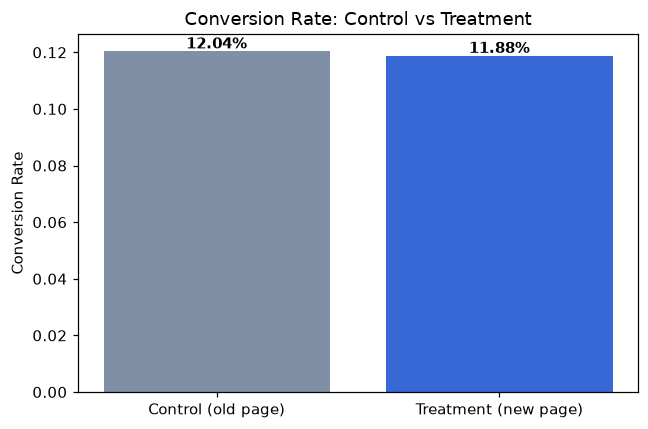

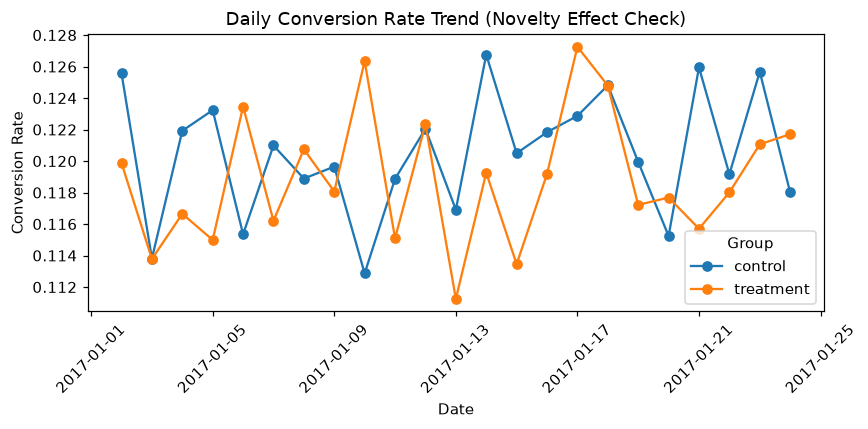

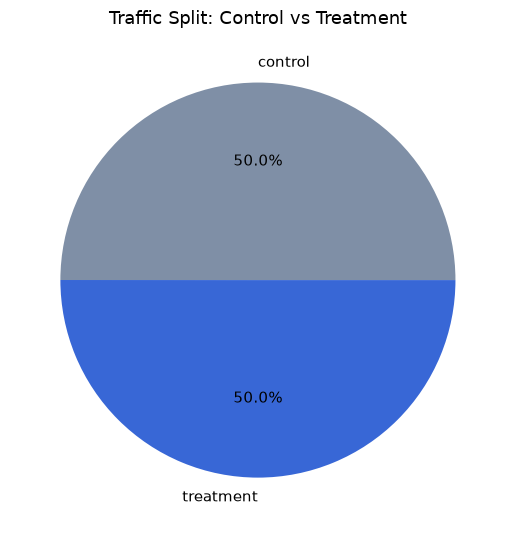

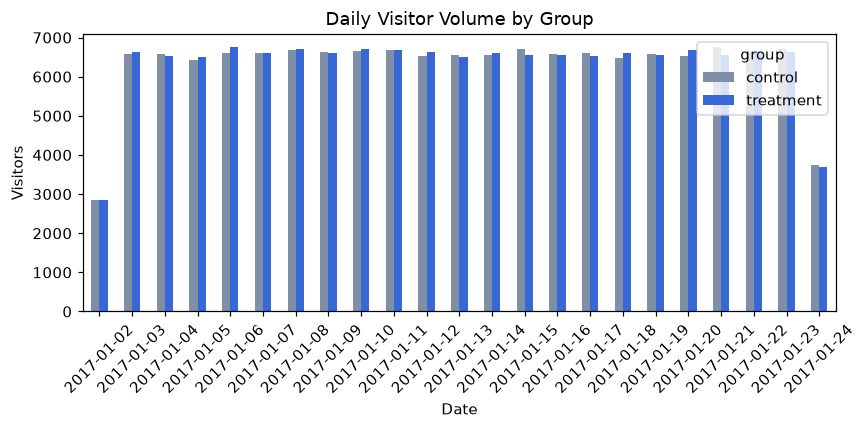

Charts saved: chart1_conversion_comparison.png, chart2_daily_trend.png,
              chart3_traffic_split.png, chart4_daily_volume.png


In [8]:
# =============================================================================
# PHASE 9: DATA VISUALIZATION
# Create charts to compare conversion rates, user distribution,
# daily trends, and other experiment insights.
# =============================================================================

# -----------------------------
# 5. Visualizations
# -----------------------------

# Chart 1: Conversion rate comparison (bar)
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Control (old page)', 'Treatment (new page)'],
       [control_rate, treatment_rate],
       color=['#7f8fa6', '#3867d6'])
ax.set_ylabel('Conversion Rate')
ax.set_title('Conversion Rate: Control vs Treatment')
for i, v in enumerate([control_rate, treatment_rate]):
    ax.text(i, v + 0.001, f'{v:.2%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
plt.savefig('chart1_conversion_comparison.png')
plt.close()

# Chart 2: Daily conversion trend
fig, ax = plt.subplots(figsize=(8, 4))
daily_pivot.plot(ax=ax, marker='o')
ax.set_ylabel('Conversion Rate')
ax.set_xlabel('Date')
ax.set_title('Daily Conversion Rate Trend (Novelty Effect Check)')
ax.legend(title='Group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig('chart2_daily_trend.png')
plt.close()

# Chart 3: Visitors per group (pie)
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(summary['visitors'], labels=summary.index, autopct='%1.1f%%',
       colors=['#7f8fa6', '#3867d6'])
ax.set_title('Traffic Split: Control vs Treatment')
plt.tight_layout()
plt.show()
plt.savefig('chart3_traffic_split.png')
plt.close()

# Chart 4: Daily visitor volume (histogram/bar)
df['date'] = pd.to_datetime(df['timestamp']).dt.date  # <-- add this line
daily_visitors = df.groupby(['date', 'group'])['user_id'].count().unstack()
fig, ax = plt.subplots(figsize=(8, 4))
daily_visitors.plot(kind='bar', ax=ax, color=['#7f8fa6', '#3867d6'])
ax.set_ylabel('Visitors')
ax.set_xlabel('Date')
ax.set_title('Daily Visitor Volume by Group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig('chart4_daily_volume.png')
plt.close()

print("Charts saved: chart1_conversion_comparison.png, chart2_daily_trend.png,")
print("              chart3_traffic_split.png, chart4_daily_volume.png")

# Save summary table for later phases
summary.to_csv('phase4_group_summary.csv')
daily_pivot.to_csv('phase4_daily_trend.csv')